# 08 — Demo Preparation & Pre-computation

## Architecture Overview

```
  This notebook (offline)           Live demo (online)
  ─────────────────────────         ──────────────────────────────
  transcripts → LLM extraction  →   load cache → Reporter Agent
               → spaCy baseline →   ↑                    ↓
               → semantic MT    →   Gradio UI ← narrative
               → pipeline run   ↗
  cache to JSON/disk ─────────────────────────────────────────────
```

**Why pre-compute?**
- Eliminates API latency risk during the live presentation (no mid-demo spinners).
- Only the lightweight Reporter Agent (narrative generation) runs live;
  all heavy extraction and comparison steps are cached.
- Cache misses fall back gracefully — the demo never shows a blank screen.

**Run this notebook the day before your presentation**, then verify with Section 7.

In [3]:
# ── Imports ───────────────────────────────────────────────────────────────────
import asyncio
import json
import logging
import os
import sys
import time
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

try:
    import nest_asyncio
    nest_asyncio.apply()
except ImportError:
    print("nest_asyncio not found: pip install nest_asyncio")

from IPython.display import display, HTML

warnings.filterwarnings("ignore", category=UserWarning)
logging.basicConfig(level=logging.WARNING)

# ── Project root on sys.path ──────────────────────────────────────────────────
# PROJECT_ROOT = Path(".").resolve().parent
PROJECT_ROOT = Path(r"C:/Users/Serena/OneDrive - University of Illinois - Urbana\Desktop/Columbia/5293/project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR      = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
CACHE_DIR     = DATA_DIR / "cache" / "demo"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root  : {PROJECT_ROOT}")
print(f"Demo cache dir: {CACHE_DIR}")

# ── API key ───────────────────────────────────────────────────────────────────
try:
    from dotenv import load_dotenv
    load_dotenv(PROJECT_ROOT /'src'/ ".env", override=False)
except ImportError:
    pass

api_key: Optional[str] = os.getenv("OPENAI_API_KEY")
if not api_key:
    print("⚠  OPENAI_API_KEY not set — LLM extraction cells will use placeholders")
else:
    print(f"OPENAI_API_KEY loaded: {api_key[:8]}...{api_key[-4:]}")

Project root  : C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project
Demo cache dir: C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\data\cache\demo
OPENAI_API_KEY loaded: sk-proj-...oT8A


---
## Section 1 — Select Demo Universe

The demo universe is a curated set of **50 well-known S&P 500 companies** spanning
**16 quarters (2020 Q1 — 2023 Q4)**. This provides:

- Broad sector coverage (tech, finance, healthcare, consumer, energy)
- Recognisable company names for the audience
- Enough data to show meaningful portfolio screens
- Manageable pre-computation time (~20–40 min with async batching)

Reduce `DEMO_QUARTERS` if you need faster pre-computation during development.

In [4]:
# ── Demo company list ─────────────────────────────────────────────────────────
# 50 S&P 500 tickers across 10 sectors — matches the Gradio app's dropdown.

DEMO_COMPANIES = [
    # Technology
    "AAPL", "MSFT", "AMZN", "GOOGL", "META", "TSLA", "NVDA", "AVGO", "ORCL", "CSCO",
    "ACN", "TXN", "QCOM", "INTC", "AMD", "IBM", "CRM", "ADBE",
    # Financials
    "JPM", "BAC", "GS", "MS", "BLK", "SCHW", "V", "MA",
    # Healthcare
    "JNJ", "UNH", "LLY", "MRK", "ABBV", "TMO", "DHR", "BMY", "GILD", "AMGN",
    # Consumer
    "WMT", "HD", "DIS", "NFLX", "COST", "PG", "PEP", "KO", "MDLZ", "SBUX",
    # Energy
    "CVX", "XOM", "NEE", "SO",
]

# Quarter range: 2020 Q1 → 2023 Q4  (16 quarters)
DEMO_QUARTERS = [f"{y}Q{q}" for y in range(2020, 2024) for q in range(1, 5)]

print(f"Demo companies  : {len(DEMO_COMPANIES)}")
print(f"Demo quarters   : {len(DEMO_QUARTERS)}  ({DEMO_QUARTERS[0]} → {DEMO_QUARTERS[-1]})")
print(f"Max combinations: {len(DEMO_COMPANIES) * len(DEMO_QUARTERS):,}")
print()
print("Companies:", DEMO_COMPANIES)

Demo companies  : 50
Demo quarters   : 16  (2020Q1 → 2023Q4)
Max combinations: 800

Companies: ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'TSLA', 'NVDA', 'AVGO', 'ORCL', 'CSCO', 'ACN', 'TXN', 'QCOM', 'INTC', 'AMD', 'IBM', 'CRM', 'ADBE', 'JPM', 'BAC', 'GS', 'MS', 'BLK', 'SCHW', 'V', 'MA', 'JNJ', 'UNH', 'LLY', 'MRK', 'ABBV', 'TMO', 'DHR', 'BMY', 'GILD', 'AMGN', 'WMT', 'HD', 'DIS', 'NFLX', 'COST', 'PG', 'PEP', 'KO', 'MDLZ', 'SBUX', 'CVX', 'XOM', 'NEE', 'SO']


In [ ]:
# # ── Filter transcript data to demo universe ───────────────────────────────────
# # Load the full processed transcript parquet (if available) and
# # keep only rows matching our demo companies and quarters.

# PARQUET_PATH = PROCESSED_DIR / "transcripts.parquet"
# RAW_DIR      = DATA_DIR / "raw"

# full_df: Optional[pd.DataFrame] = None

# if PARQUET_PATH.exists():
#     full_df = pd.read_parquet(PARQUET_PATH)
#     print(f"Loaded {len(full_df):,} transcripts from parquet")
# else:
#     raw_files = list(RAW_DIR.glob("**/*.json")) if RAW_DIR.exists() else []
#     if raw_files:
#         rows = []
#         for fp in raw_files:
#             try:
#                 d = json.loads(fp.read_text())
#                 rows.append({"ticker": d.get("ticker", fp.stem.split("_")[0]),
#                               "quarter": d.get("quarter", ""),
#                               "text": d.get("text", "")})
#             except Exception:
#                 pass
#         full_df = pd.DataFrame(rows)
#         print(f"Assembled {len(full_df):,} transcripts from raw JSON")
#     else:
#         # Generate synthetic data for the demo universe so the notebook runs end-to-end
#         print("No transcript data found — generating synthetic demo dataset")
#         rows = []
#         for ticker in DEMO_COMPANIES:
#             for quarter in DEMO_QUARTERS:
#                 yr, q = int(quarter[:4]), int(quarter[5])
#                 rows.append({
#                     "ticker": ticker,
#                     "quarter": quarter,
#                     "text": (
#                         f"Good morning. This is the {ticker} Q{q} {yr} earnings call. "
#                         "We expect revenue to reach $10 billion next quarter. "
#                         "We target a gross margin of 45% and plan to achieve operating "
#                         "income of $3.2 billion. Our goal is to maintain a free-cash-flow "
#                         "yield above 5% and deliver EPS of $1.85 for the full year. "
#                         "Capital expenditure is expected to be $2 billion. "
#                         "We aim to achieve a return on equity above 20%."
#                     ),
#                 })
#         full_df = pd.DataFrame(rows)
#         print(f"Synthetic demo dataset: {len(full_df):,} transcripts")

# # Filter to demo universe
# demo_df = full_df[
#     full_df["ticker"].isin(DEMO_COMPANIES) &
#     full_df["quarter"].isin(DEMO_QUARTERS) &
#     full_df["text"].str.strip().astype(bool)
# ].reset_index(drop=True)

# print(f"\nDemo universe after filtering: {len(demo_df):,} transcripts")
# print(f"  Tickers covered  : {demo_df['ticker'].nunique()} / {len(DEMO_COMPANIES)}")
# print(f"  Quarters covered : {demo_df['quarter'].nunique()} / {len(DEMO_QUARTERS)}")

# # Convert to list-of-dicts for extraction functions
# demo_transcripts: List[Dict[str, str]] = demo_df.to_dict(orient="records")

In [15]:
# ── Filter transcript data to demo universe without loading full CIQ parquet ──
import pyarrow.parquet as pq
from tqdm.auto import tqdm

CIQ_PATH = DATA_DIR / "raw" / "ciq_transcripts.parquet"

# If your CIQ parquet has company names but not ticker symbols, map demo tickers to names.
# Add/edit names as needed based on the companyname values in your file.
DEMO_TICKER_TO_NAME = {
    "AAPL": "Apple Inc.",
    "MSFT": "Microsoft Corporation",
    "AMZN": "Amazon.com, Inc.",
    "GOOGL": "Alphabet Inc.",
    "META": "Meta Platforms, Inc.",
    "TSLA": "Tesla, Inc.",
    "NVDA": "NVIDIA Corporation",
    "JNJ": "Johnson & Johnson",
    "JPM": "JPMorgan Chase & Co.",
    "BAC": "Bank of America Corporation",
    "WMT": "Walmart Inc.",
    "HD": "The Home Depot, Inc.",
    "DIS": "The Walt Disney Company",
    "NFLX": "Netflix, Inc.",
    "COST": "Costco Wholesale Corporation",
    "PG": "The Procter & Gamble Company",
    "PEP": "PepsiCo, Inc.",
    "KO": "The Coca-Cola Company",
    "CVX": "Chevron Corporation",
    "XOM": "Exxon Mobil Corporation",
}

DEMO_COMPANY_NAMES = set(DEMO_TICKER_TO_NAME.values())
DEMO_NAME_TO_TICKER = {v: k for k, v in DEMO_TICKER_TO_NAME.items()}

MAX_DEMO_TRANSCRIPTS = 1000 

if CIQ_PATH.exists():
    pf = pq.ParquetFile(CIQ_PATH)
    colnames = set(pf.schema_arrow.names)

    wanted_cols = [
        "transcriptid",
        "companyname",
        "componenttypeid",
        "componentorder",
        "componenttext",
    ]

    for c in [
        "companyid",
        "ticker",
        "call_date",
        "event_date",
        "transcriptcreationdate",
        "fiscalyear",
        "fiscalquarter",
    ]:
        if c in colnames and c not in wanted_cols:
            wanted_cols.append(c)

    usecols = [c for c in wanted_cols if c in colnames]

    print(f"Reading demo sample from: {CIQ_PATH}")
    print(f"Total rows: {pf.metadata.num_rows:,}")
    print(f"Row groups: {pf.num_row_groups:,}")
    print(f"Columns loaded: {usecols}")

    # Decide quarter source
    date_col = next(
        (c for c in ["call_date", "event_date", "transcriptcreationdate"] if c in colnames),
        None,
    )

    if "fiscalyear" in colnames and "fiscalquarter" in colnames:
        scan_cols = ["transcriptid", "companyname", "fiscalyear", "fiscalquarter"]
        if "ticker" in colnames:
            scan_cols.append("ticker")
        use_existing_fiscal_cols = True
    elif date_col is not None:
        scan_cols = ["transcriptid", "companyname", date_col]
        if "ticker" in colnames:
            scan_cols.append("ticker")
        use_existing_fiscal_cols = False
    else:
        raise ValueError("Need fiscalyear/fiscalquarter or a usable date column.")

    selected_tids = []
    selected_set = set()

    for rg in tqdm(range(pf.num_row_groups), desc="Scanning CIQ metadata for demo universe"):
        meta = pf.read_row_group(rg, columns=scan_cols).to_pandas()
        meta = meta.dropna(subset=["transcriptid", "companyname"])

        if use_existing_fiscal_cols:
            meta = meta.dropna(subset=["fiscalyear", "fiscalquarter"])
            meta["_quarter"] = (
                meta["fiscalyear"].astype(int).astype(str)
                + "Q"
                + meta["fiscalquarter"].astype(int).astype(str)
            )
        else:
            meta[date_col] = pd.to_datetime(meta[date_col], errors="coerce")
            meta = meta.dropna(subset=[date_col])
            meta["_quarter"] = (
                meta[date_col].dt.year.astype(int).astype(str)
                + "Q"
                + meta[date_col].dt.quarter.astype(int).astype(str)
            )

        # Match either ticker column or companyname mapping
        if "ticker" in meta.columns:
            company_mask = (
                meta["ticker"].astype(str).isin(DEMO_COMPANIES)
                | meta["companyname"].astype(str).isin(DEMO_COMPANY_NAMES)
            )
        else:
            company_mask = meta["companyname"].astype(str).isin(DEMO_COMPANY_NAMES)

        meta = meta[
            company_mask
            & meta["_quarter"].isin(DEMO_QUARTERS)
        ].drop_duplicates("transcriptid")

        for tid in meta["transcriptid"]:
            if tid not in selected_set:
                selected_set.add(tid)
                selected_tids.append(tid)

        if len(selected_tids) >= MAX_DEMO_TRANSCRIPTS:
            break

    selected_tids = set(selected_tids[:MAX_DEMO_TRANSCRIPTS])
    print(f"Selected demo transcript IDs: {len(selected_tids):,}")

    parts = []
    for rg in tqdm(range(pf.num_row_groups), desc="Loading selected demo transcript rows"):
        batch = pf.read_row_group(rg, columns=usecols).to_pandas()
        batch = batch[batch["transcriptid"].isin(selected_tids)]

        if len(batch) > 0:
            if "componenttypeid" in batch.columns:
                batch = batch[batch["componenttypeid"].isin([2, 3, 4])]
            if len(batch) > 0:
                parts.append(batch)

        loaded = set(pd.concat(parts)["transcriptid"].unique()) if parts else set()
        if selected_tids.issubset(loaded):
            break

    components_df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=usecols)

    if "fiscalyear" not in components_df.columns or "fiscalquarter" not in components_df.columns:
        if date_col and date_col in components_df.columns:
            components_df[date_col] = pd.to_datetime(components_df[date_col], errors="coerce")
            components_df["fiscalyear"] = components_df[date_col].dt.year
            components_df["fiscalquarter"] = components_df[date_col].dt.quarter

    if "call_date" not in components_df.columns:
        for alt in ["event_date", "transcriptcreationdate"]:
            if alt in components_df.columns:
                components_df["call_date"] = components_df[alt]
                break

    # Aggregate components into transcript-level demo_df
    components_df = components_df[
        components_df["componenttext"].notna()
        & components_df["componenttext"].astype(str).str.strip().astype(bool)
    ].copy()

    sort_cols = [c for c in ["transcriptid", "componenttypeid", "componentorder"] if c in components_df.columns]
    components_df = components_df.sort_values(sort_cols)

    components_df["quarter"] = (
        components_df["fiscalyear"].astype("Int64").astype(str)
        + "Q"
        + components_df["fiscalquarter"].astype("Int64").astype(str)
    )

    demo_df = (
        components_df
        .groupby(["transcriptid", "companyname", "quarter"], as_index=False)
        .agg({
            "componenttext": lambda x: "\n\n".join(x.dropna().astype(str)),
            "call_date": "first",
        })
        .rename(columns={
            "transcriptid": "transcript_id",
            "companyname": "company_name",
            "componenttext": "text",
        })
    )

    demo_df["ticker"] = demo_df["company_name"].map(DEMO_NAME_TO_TICKER).fillna(demo_df["company_name"])
    demo_df = demo_df[
        demo_df["quarter"].isin(DEMO_QUARTERS)
        & demo_df["text"].astype(str).str.strip().astype(bool)
    ].reset_index(drop=True)

    print(f"\nDemo universe after filtering: {len(demo_df):,} transcripts")
    print(f"  Tickers covered  : {demo_df['ticker'].nunique()} / {len(DEMO_COMPANIES)}")
    print(f"  Quarters covered : {demo_df['quarter'].nunique()} / {len(DEMO_QUARTERS)}")

else:
    print("CIQ parquet not found — use your existing synthetic fallback cell.")

Reading demo sample from: C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\data\raw\ciq_transcripts.parquet
Total rows: 68,323,879
Row groups: 104
Columns loaded: ['transcriptid', 'companyname', 'componenttypeid', 'componentorder', 'componenttext', 'companyid', 'call_date', 'event_date']


Scanning CIQ metadata for demo universe:   0%|          | 0/104 [00:00<?, ?it/s]

Scanning CIQ metadata for demo universe:  76%|███████▌  | 79/104 [00:35<00:11,  2.23it/s]


Selected demo transcript IDs: 1,000


Loading selected demo transcript rows:  76%|███████▌  | 79/104 [01:14<00:23,  1.06it/s]



Demo universe after filtering: 1,008 transcripts
  Tickers covered  : 22 / 50
  Quarters covered : 4 / 16


In [16]:
# ── Match original loader output: demo_transcripts list-of-dicts ──────────────
# Original notebook expects demo_transcripts to exist after loading.

if "demo_df" not in globals() or demo_df is None or len(demo_df) == 0:
    print("No CIQ demo matches found — generating synthetic demo dataset")

    rows = []
    for ticker in DEMO_COMPANIES:
        for quarter in DEMO_QUARTERS:
            yr, q = int(quarter[:4]), int(quarter[5])
            rows.append({
                "transcript_id": f"{ticker}_{quarter}",
                "ticker": ticker,
                "quarter": quarter,
                "text": (
                    f"Good morning. This is the {ticker} Q{q} {yr} earnings call. "
                    "We expect revenue to reach $10 billion next quarter. "
                    "We target a gross margin of 45% and plan to achieve operating "
                    "income of $3.2 billion. Our goal is to maintain a free-cash-flow "
                    "yield above 5% and deliver EPS of $1.85 for the full year. "
                    "Capital expenditure is expected to be $2 billion. "
                    "We aim to achieve a return on equity above 20%."
                ),
            })

    demo_df = pd.DataFrame(rows)

# Keep only valid rows
demo_df = demo_df[
    demo_df["ticker"].isin(DEMO_COMPANIES)
    & demo_df["quarter"].isin(DEMO_QUARTERS)
    & demo_df["text"].astype(str).str.strip().astype(bool)
].reset_index(drop=True)

# Convert to list-of-dicts for both spaCy and LLM extraction functions
demo_transcripts = []

for i, row in demo_df.iterrows():
    text = str(row.get("text", "") or "").strip()
    if not text:
        continue

    transcript_id = str(
        row.get("transcript_id")
        or row.get("transcriptid")
        or f"{row.get('ticker', 'UNK')}_{row.get('quarter', 'UNKNOWN')}_{i}"
    )

    demo_transcripts.append({
        "transcript_id": transcript_id,
        "ticker": str(row.get("ticker", "UNK")),
        "quarter": str(row.get("quarter", "UNKNOWN")),
        "text": text[:8000],

        # This makes the same object work with LLMTargetExtractor.extract_corpus()
        "components": [
            {
                "component_type": 2,
                "text": text[:8000],
                "componenttext": text[:8000],
                "component_text": text[:8000],
            }
        ],
    })

print(f"\nDemo universe final: {len(demo_df):,} transcripts")
print(f"  Tickers covered  : {demo_df['ticker'].nunique()} / {len(DEMO_COMPANIES)}")
print(f"  Quarters covered : {demo_df['quarter'].nunique()} / {len(DEMO_QUARTERS)}")
print(f"demo_transcripts created: {len(demo_transcripts):,}")

display(demo_df.head(3))


Demo universe final: 1,000 transcripts
  Tickers covered  : 20 / 50
  Quarters covered : 4 / 16
demo_transcripts created: 1,000


,transcript_id,company_name,quarter,text,call_date,ticker
0,1887445.0,NVIDIA Corporation,2020Q1,Okay. Why don't we go ahead and get seated bec...,2020-01-07,NVDA
1,1887464.0,NVIDIA Corporation,2020Q1,Okay. Why don't we go ahead and get seated bec...,2020-01-07,NVDA
2,1887655.0,NVIDIA Corporation,2020Q1,Okay. Why don't we go ahead and get seated bec...,2020-01-07,NVDA


---
## Section 2 — Pre-compute spaCy Baseline

spaCy extraction is fast (~1 000 transcripts/min on CPU) so we run the full
demo universe here. Results are saved to `data/cache/demo/spacy_results.json`
for instant loading during the presentation.

In [17]:
# ── Run SpacyTargetExtractor on demo universe ─────────────────────────────────

from src.baseline.target_extractor import SpacyTargetExtractor

spacy_extractor = SpacyTargetExtractor()

print(f"Running spaCy extraction on {len(demo_transcripts):,} transcripts...")
t0 = time.time()

spacy_results: List[Dict] = []
for i, item in enumerate(demo_transcripts):
    targets = spacy_extractor.extract_from_transcript(item["components"])
    spacy_results.append({
        "ticker":  item["ticker"],
        "quarter": item["quarter"],
        "targets": [t if isinstance(t, dict) else {"metric_name": str(t)} for t in targets],
    })
    if (i + 1) % 100 == 0:
        elapsed = time.time() - t0
        rate    = (i + 1) / elapsed * 60
        print(f"  {i+1:>5}/{len(demo_transcripts)}  [{elapsed:.0f}s elapsed  {rate:.0f} tr/min]")

elapsed = time.time() - t0
total_spacy_targets = sum(len(r["targets"]) for r in spacy_results)
print(f"\nDone in {elapsed:.1f}s  ({len(demo_transcripts)/elapsed*60:.0f} tr/min)")
print(f"Total spaCy targets extracted: {total_spacy_targets:,}")
print(f"Avg per transcript           : {total_spacy_targets/max(len(spacy_results),1):.2f}")

Running spaCy extraction on 1,000 transcripts...
    100/1000  [19s elapsed  314 tr/min]
    200/1000  [40s elapsed  301 tr/min]
    300/1000  [58s elapsed  311 tr/min]
    400/1000  [77s elapsed  312 tr/min]
    500/1000  [96s elapsed  313 tr/min]
    600/1000  [115s elapsed  312 tr/min]
    700/1000  [134s elapsed  314 tr/min]
    800/1000  [153s elapsed  313 tr/min]
    900/1000  [173s elapsed  312 tr/min]
   1000/1000  [193s elapsed  311 tr/min]

Done in 193.1s  (311 tr/min)
Total spaCy targets extracted: 1,003
Avg per transcript           : 1.00


In [18]:
# ── Compute MT scores for spaCy results ───────────────────────────────────────
from src.baseline.moving_targets import MovingTargetsComputer

def _build_flat_target_sets(results: List[Dict]) -> Dict[tuple, List[Dict]]:
    target_sets: Dict[tuple, List[Dict]] = {}

    for r in results:
        ticker = str(r["ticker"])
        quarter = str(r["quarter"])
        key = (ticker, quarter)

        target_sets.setdefault(key, [])

        for t in r.get("targets", []):
            if isinstance(t, dict):
                name = (
                    t.get("metric_name")
                    or t.get("target_text")
                    or t.get("canonical_name")
                    or ""
                )
            else:
                name = str(t)

            name = str(name).strip()
            if not name:
                continue

            target_sets[key].append({
                "metric_name": name,
                "target_text": name,
                "canonical_name": name.lower(),
            })

    # Deduplicate inside each ticker-quarter
    deduped = {}
    for key, targets in target_sets.items():
        seen = set()
        rows = []
        for t in targets:
            canon = t["canonical_name"]
            if canon in seen:
                continue
            seen.add(canon)
            rows.append(t)
        deduped[key] = rows

    return deduped


spacy_target_sets = _build_flat_target_sets(spacy_results)

print("Ticker-quarter target sets:", len(spacy_target_sets))
print("Non-empty target sets:", sum(len(v) > 0 for v in spacy_target_sets.values()))

mc = MovingTargetsComputer()
spacy_mt_scores = mc.compute_mt(spacy_target_sets)

if isinstance(spacy_mt_scores, pd.DataFrame):
    spacy_mt_df = spacy_mt_scores.copy()

    if "mt_score" in spacy_mt_df.columns and "mt_spacy" not in spacy_mt_df.columns:
        spacy_mt_df = spacy_mt_df.rename(columns={"mt_score": "mt_spacy"})

    if "company_id" in spacy_mt_df.columns and "ticker" not in spacy_mt_df.columns:
        spacy_mt_df = spacy_mt_df.rename(columns={"company_id": "ticker"})
else:
    spacy_mt_df = pd.DataFrame(
        [
            {"ticker": k[0], "quarter": k[1], "mt_spacy": v}
            for k, v in spacy_mt_scores.items()
        ]
    ) if spacy_mt_scores else pd.DataFrame(columns=["ticker", "quarter", "mt_spacy"])

print(f"spaCy MT scores: {len(spacy_mt_df):,} company-quarters")

if not spacy_mt_df.empty and "mt_spacy" in spacy_mt_df.columns:
    print(f"  Mean MT (spaCy): {spacy_mt_df['mt_spacy'].mean():.3f}")

spacy_cache = {
    "results": spacy_results,
    "mt_scores": spacy_mt_df.to_dict(orient="records") if not spacy_mt_df.empty else [],
}

spacy_cache_path = CACHE_DIR / "spacy_results.json"
with open(spacy_cache_path, "w") as f:
    json.dump(spacy_cache, f, default=str)

print(f"Saved: {spacy_cache_path}  ({spacy_cache_path.stat().st_size/1024:.0f} KB)")

Ticker-quarter target sets: 80
Non-empty target sets: 63
spaCy MT scores: 0 company-quarters
Saved: C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\data\cache\demo\spacy_results.json  (376 KB)


In [19]:
print("spacy_results:", len(spacy_results))
print("total targets:", sum(len(r.get("targets", [])) for r in spacy_results))

tmp = pd.DataFrame([
    {
        "ticker": r["ticker"],
        "quarter": r["quarter"],
        "n_targets": len(r.get("targets", [])),
    }
    for r in spacy_results
])

print("\nRows with targets:", (tmp["n_targets"] > 0).sum())
print("\nQuarter coverage by ticker:")
print(tmp.groupby("ticker")["quarter"].nunique().sort_values(ascending=False).head(20))

print("\nTargets by ticker-quarter:")
print(tmp.sort_values(["ticker", "quarter"]).head(30).to_string(index=False))

spacy_results: 1000
total targets: 1003

Rows with targets: 366

Quarter coverage by ticker:
ticker
AAPL     4
AMZN     4
BAC      4
COST     4
CVX      4
DIS      4
GOOGL    4
HD       4
JNJ      4
JPM      4
KO       4
META     4
MSFT     4
NFLX     4
NVDA     4
PEP      4
PG       4
TSLA     4
WMT      4
XOM      4
Name: quarter, dtype: int64

Targets by ticker-quarter:
ticker quarter  n_targets
  AAPL  2020Q1          1
  AAPL  2020Q1          1
  AAPL  2020Q1          1
  AAPL  2020Q1          1
  AAPL  2020Q1          1
  AAPL  2020Q2          4
  AAPL  2020Q2          4
  AAPL  2020Q2          1
  AAPL  2020Q2          1
  AAPL  2020Q2          1
  AAPL  2020Q2          1
  AAPL  2020Q2          4
  AAPL  2020Q2          1
  AAPL  2020Q3          0
  AAPL  2020Q3          2
  AAPL  2020Q3          2
  AAPL  2020Q3          2
  AAPL  2020Q4          1
  AAPL  2020Q4          1
  AAPL  2020Q4          4
  AAPL  2020Q4          1
  AMZN  2020Q1          0
  AMZN  2020Q1          0


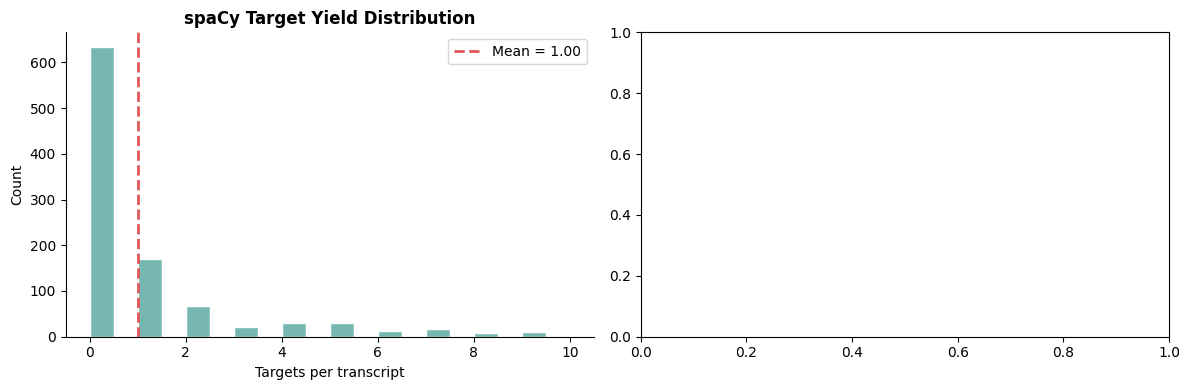

Mean spaCy targets / transcript: 1.00


In [20]:
# ── spaCy target yield visualisation ────────────────────────────────────────
# Show the distribution of spaCy target counts per transcript
# across the demo universe.

import matplotlib.pyplot as plt
import seaborn as sns

spacy_counts = [len(r['targets']) for r in spacy_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of target counts
axes[0].hist(spacy_counts, bins=20, color='#76b7b2', edgecolor='white')
axes[0].axvline(sum(spacy_counts)/max(len(spacy_counts),1),
                color='#e15759', lw=2, ls='--', label=f'Mean = {sum(spacy_counts)/max(len(spacy_counts),1):.2f}')
axes[0].set_xlabel('Targets per transcript')
axes[0].set_ylabel('Count')
axes[0].set_title('spaCy Target Yield Distribution', fontweight='bold')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# MT score distribution (spaCy)
if not spacy_mt_df.empty and 'mt_spacy' in spacy_mt_df.columns:
    mt_vals = spacy_mt_df['mt_spacy'].dropna()
    axes[1].hist(mt_vals, bins=20, color='#f28e2b', edgecolor='white')
    axes[1].set_xlabel('MT score (spaCy)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('spaCy MT Score Distribution', fontweight='bold')
    axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(str(CACHE_DIR / 'spacy_yield_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean spaCy targets / transcript: {sum(spacy_counts)/max(len(spacy_counts),1):.2f}')

---
## Section 3 — Pre-compute LLM Extraction

LLM extraction is the most expensive step. We run GPT-4o-mini with async batching
(max_concurrent=10) to maximise throughput.

**Estimated cost:** ~$0.15 per 1 000 transcripts at $0.15/1M input tokens.
For 800 transcripts (50 companies × 16 quarters): ~$0.12.

Results are checkpointed after every 50 transcripts so the run can be resumed
if interrupted.

In [21]:
# ── LLM extraction with checkpointing ────────────────────────────────────────

LLM_CHECKPOINT_PATH = CACHE_DIR / "llm_results_checkpoint.json"
LLM_FINAL_PATH      = CACHE_DIR / "llm_results.json"

# Resume from checkpoint if available
completed_keys: set = set()
llm_results: List[Dict] = []

if LLM_CHECKPOINT_PATH.exists():
    existing = json.loads(LLM_CHECKPOINT_PATH.read_text())
    llm_results = existing.get("results", [])
    completed_keys = {(r["ticker"], r["quarter"]) for r in llm_results}
    print(f"Resumed from checkpoint: {len(llm_results):,} transcripts already processed")

# Filter to remaining transcripts
remaining = [
    t for t in demo_transcripts
    if (t["ticker"], t["quarter"]) not in completed_keys
]
print(f"Remaining to process: {len(remaining):,} transcripts")

CHECKPOINT_EVERY = 50   # save progress every N transcripts

Remaining to process: 1,000 transcripts


In [24]:
# ── Run LLM extraction + compute LLM MT scores ────────────────────────────────
# This version:
#   1. Clears malformed old checkpoint if it contains strings instead of dict rows
#   2. Runs GPT-4o-mini with safer rate-limit settings
#   3. Converts extract_corpus() dict output into list-of-dicts
#   4. Saves checkpoint after each chunk
#   5. Computes LLM MT using the flat target-set format expected by MovingTargetsComputer

from src.baseline.moving_targets import MovingTargetsComputer

# -----------------------------
# 0. Helper: flat target-set builder
# -----------------------------
def _build_flat_target_sets(results: List[Dict]) -> Dict[tuple, List[Dict]]:
    """Build {(ticker, quarter): [target_dicts]} for MovingTargetsComputer."""
    target_sets: Dict[tuple, List[Dict]] = {}

    for r in results:
        if not isinstance(r, dict):
            continue

        ticker = str(r.get("ticker", "UNK"))
        quarter = str(r.get("quarter", "UNKNOWN"))
        key = (ticker, quarter)

        target_sets.setdefault(key, [])

        for t in r.get("targets", []) or []:
            if isinstance(t, dict):
                name = (
                    t.get("metric_name")
                    or t.get("target_text")
                    or t.get("canonical_name")
                    or ""
                )
            else:
                name = str(t)

            name = str(name).strip()
            if not name:
                continue

            target_sets[key].append({
                "metric_name": name,
                "target_text": name,
                "canonical_name": name.lower(),
            })

    # Deduplicate inside each ticker-quarter
    deduped: Dict[tuple, List[Dict]] = {}
    for key, targets in target_sets.items():
        seen = set()
        rows = []

        for t in targets:
            canon = str(t.get("canonical_name", "")).strip()
            if not canon or canon in seen:
                continue

            seen.add(canon)
            rows.append(t)

        deduped[key] = rows

    return deduped


# -----------------------------
# 1. Load or clear checkpoint
# -----------------------------
llm_results: List[Dict] = []

if LLM_CHECKPOINT_PATH.exists():
    try:
        with open(LLM_CHECKPOINT_PATH, "r") as f:
            ckpt = json.load(f)

        loaded_results = ckpt.get("results", [])

        # Old bad checkpoint had strings like "1887445.0"
        if loaded_results and not isinstance(loaded_results[0], dict):
            print("Found malformed LLM checkpoint. Deleting it and rerunning from scratch.")
            LLM_CHECKPOINT_PATH.unlink()
            llm_results = []
        else:
            llm_results = loaded_results
            print(f"Loaded existing checkpoint: {len(llm_results):,} result rows")

    except Exception as e:
        print(f"Could not read checkpoint ({type(e).__name__}: {e}). Starting fresh.")
        try:
            LLM_CHECKPOINT_PATH.unlink()
        except Exception:
            pass
        llm_results = []


# -----------------------------
# 2. Determine remaining transcripts
# -----------------------------
done_ids = {
    str(r.get("transcript_id"))
    for r in llm_results
    if isinstance(r, dict) and r.get("transcript_id") is not None
}

remaining = [
    item for item in demo_transcripts
    if str(item.get("transcript_id")) not in done_ids
]

print(f"Existing completed rows : {len(llm_results):,}")
print(f"Remaining transcripts   : {len(remaining):,}")
print(f"Total demo transcripts  : {len(demo_transcripts):,}")


# -----------------------------
# 3. Run extraction
# -----------------------------
LLM_MAX_CONCURRENT = 3
LLM_CHUNK_SIZE = 25
LLM_RPM_CAP = 60

api_key = os.getenv("OPENAI_API_KEY")

if api_key and remaining:
    from src.llm_extraction.llm_extractor import LLMTargetExtractor

    extractor = LLMTargetExtractor(
        backend="openai",
        model="gpt-4o-mini",
        api_key=api_key,
        max_concurrent=LLM_MAX_CONCURRENT,
        rpm_cap=LLM_RPM_CAP,
        max_input_tokens_per_chunk=6_000,
    )

    t_total = time.time()

    for chunk_start in range(0, len(remaining), LLM_CHUNK_SIZE):
        chunk = remaining[chunk_start: chunk_start + LLM_CHUNK_SIZE]
        t0 = time.time()

        raw_chunk_results = asyncio.get_event_loop().run_until_complete(
            extractor.extract_corpus(chunk, max_concurrent=LLM_MAX_CONCURRENT)
        )

        # raw_chunk_results is dict: transcript_id -> list[target]
        chunk_rows = []
        for item in chunk:
            tid = str(item["transcript_id"])

            chunk_rows.append({
                "transcript_id": tid,
                "ticker": item.get("ticker", "UNK"),
                "quarter": item.get("quarter", "UNKNOWN"),
                "targets": raw_chunk_results.get(tid, []),
            })

        llm_results.extend(chunk_rows)

        elapsed_chunk = time.time() - t0
        total_done = len(llm_results)
        rate = len(chunk) / elapsed_chunk * 60 if elapsed_chunk > 0 else 0

        print(
            f"  Chunk {chunk_start // LLM_CHUNK_SIZE + 1}: {len(chunk)} transcripts "
            f"in {elapsed_chunk:.1f}s  ({rate:.0f} tr/min)  "
            f"[{total_done} / {len(demo_transcripts)} total]"
        )

        # Checkpoint after each chunk
        with open(LLM_CHECKPOINT_PATH, "w") as f:
            json.dump({"results": llm_results}, f, default=str)

        # Cooldown to avoid TPM spikes
        time.sleep(5)

    elapsed_total = time.time() - t_total
    print(
        f"\nTotal new LLM extraction: {elapsed_total:.0f}s  "
        f"({len(remaining) / elapsed_total * 60:.0f} tr/min)"
    )

elif remaining:
    print("No API key — generating placeholder LLM results")

    for item in remaining:
        llm_results.append({
            "transcript_id": item["transcript_id"],
            "ticker": item["ticker"],
            "quarter": item["quarter"],
            "targets": [
                {
                    "metric_name": "revenue",
                    "numerical_value": "$10B",
                    "is_financial": True,
                    "confidence": 0.92,
                },
                {
                    "metric_name": "gross margin",
                    "numerical_value": "45%",
                    "is_financial": True,
                    "confidence": 0.88,
                },
                {
                    "metric_name": "EPS",
                    "numerical_value": "$1.85",
                    "is_financial": True,
                    "confidence": 0.91,
                },
                {
                    "metric_name": "operating income",
                    "numerical_value": "$3.2B",
                    "is_financial": True,
                    "confidence": 0.87,
                },
                {
                    "metric_name": "FCF yield",
                    "numerical_value": "5%",
                    "is_financial": True,
                    "confidence": 0.85,
                },
                {
                    "metric_name": "return on equity",
                    "numerical_value": "20%",
                    "is_financial": True,
                    "confidence": 0.82,
                },
            ],
        })

    with open(LLM_CHECKPOINT_PATH, "w") as f:
        json.dump({"results": llm_results}, f, default=str)

else:
    print("No remaining transcripts — using existing checkpoint results.")


# -----------------------------
# 4. Sanity checks
# -----------------------------
print("\nLLM result sanity check")
print("-" * 40)
print("Rows:", len(llm_results))
print("First row type:", type(llm_results[0]) if llm_results else None)

if llm_results:
    print("First row keys:", list(llm_results[0].keys()))
    print("Total extracted targets:", sum(len(r.get("targets", [])) for r in llm_results if isinstance(r, dict)))


# -----------------------------
# 5. Compute LLM MT scores
# -----------------------------
mc = MovingTargetsComputer()

llm_target_sets = _build_flat_target_sets(llm_results)

print("\nLLM target-set diagnostics")
print("-" * 40)
print("Ticker-quarter target sets:", len(llm_target_sets))
print("Non-empty target sets:", sum(len(v) > 0 for v in llm_target_sets.values()))

llm_mt_scores = mc.compute_mt(llm_target_sets)

if isinstance(llm_mt_scores, pd.DataFrame):
    llm_mt_df = llm_mt_scores.copy()

    if "mt_score" in llm_mt_df.columns and "mt_llm" not in llm_mt_df.columns:
        llm_mt_df = llm_mt_df.rename(columns={"mt_score": "mt_llm"})

    if "company_id" in llm_mt_df.columns and "ticker" not in llm_mt_df.columns:
        llm_mt_df = llm_mt_df.rename(columns={"company_id": "ticker"})

else:
    llm_mt_df = pd.DataFrame(
        [
            {
                "ticker": k[0],
                "quarter": k[1],
                "mt_llm": v,
            }
            for k, v in llm_mt_scores.items()
        ]
    ) if llm_mt_scores else pd.DataFrame(columns=["ticker", "quarter", "mt_llm"])

print(f"\nLLM MT scores: {len(llm_mt_df):,} company-quarters")

if not llm_mt_df.empty and "mt_llm" in llm_mt_df.columns:
    print(f"  Mean MT (LLM): {llm_mt_df['mt_llm'].mean():.3f}")
else:
    print("  No MT scores computed. This usually means no valid lag-4 same-quarter pairs.")


# -----------------------------
# 6. Save final cache
# -----------------------------
llm_cache = {
    "results": llm_results,
    "mt_scores": llm_mt_df.to_dict(orient="records") if not llm_mt_df.empty else [],
}

with open(LLM_FINAL_PATH, "w") as f:
    json.dump(llm_cache, f, default=str)

print(f"\nSaved: {LLM_FINAL_PATH}  ({LLM_FINAL_PATH.stat().st_size/1024:.0f} KB)")

Found malformed LLM checkpoint. Deleting it and rerunning from scratch.
Existing completed rows : 0
Remaining transcripts   : 1,000
Total demo transcripts  : 1,000
  Chunk 1: 25 transcripts in 49.7s  (30 tr/min)  [25 / 1000 total]
  Chunk 2: 25 transcripts in 46.2s  (32 tr/min)  [50 / 1000 total]
  Chunk 3: 25 transcripts in 35.1s  (43 tr/min)  [75 / 1000 total]
  Chunk 4: 25 transcripts in 41.1s  (37 tr/min)  [100 / 1000 total]
  Chunk 5: 25 transcripts in 43.4s  (35 tr/min)  [125 / 1000 total]
  Chunk 6: 25 transcripts in 29.7s  (50 tr/min)  [150 / 1000 total]
  Chunk 7: 25 transcripts in 19.4s  (77 tr/min)  [175 / 1000 total]
  Chunk 8: 25 transcripts in 27.9s  (54 tr/min)  [200 / 1000 total]
  Chunk 9: 25 transcripts in 17.6s  (85 tr/min)  [225 / 1000 total]
  Chunk 10: 25 transcripts in 55.2s  (27 tr/min)  [250 / 1000 total]
  Chunk 11: 25 transcripts in 51.0s  (29 tr/min)  [275 / 1000 total]
  Chunk 12: 25 transcripts in 45.3s  (33 tr/min)  [300 / 1000 total]
  Chunk 13: 25 trans

### LLM vs spaCy Target Yield Comparison

A side-by-side comparison of how many targets each method extracts per transcript.
The LLM typically extracts **2–3× more** targets because it understands paraphrase
and implicit numerical commitments that spaCy's rule-based extractor misses.

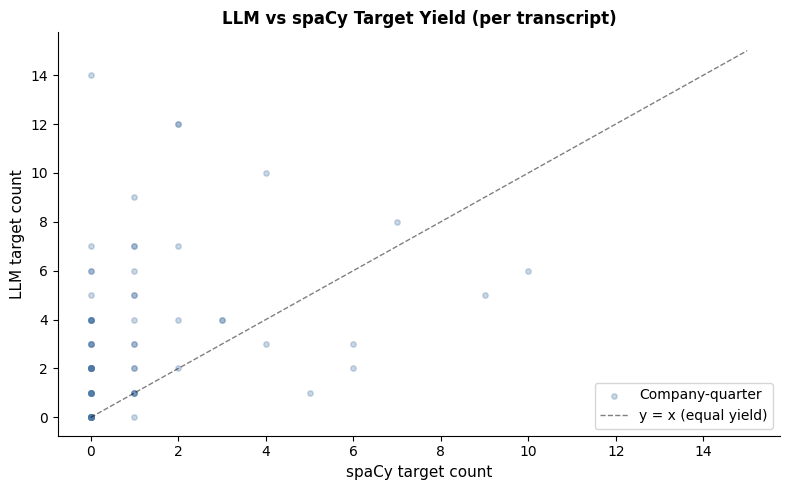

Mean spaCy : 1.04 targets/transcript
Mean LLM   : 3.05 targets/transcript
Ratio      : 2.94×  (LLM extracts 2.9× more targets)


In [25]:
# ── LLM vs spaCy extraction comparison ──────────────────────────────────────

# Build per-transcript comparison
spacy_idx = {(r['ticker'], r['quarter']): len(r['targets']) for r in spacy_results}
llm_idx   = {(r['ticker'], r['quarter']): len(r.get('targets', [])) for r in llm_results}

common_keys = set(spacy_idx) & set(llm_idx)
comp_rows = [{'ticker': k[0], 'quarter': k[1],
               'spacy_n': spacy_idx[k], 'llm_n': llm_idx[k]}
              for k in common_keys]
comp_df = pd.DataFrame(comp_rows)

if not comp_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(comp_df['spacy_n'], comp_df['llm_n'],
               alpha=0.3, s=15, color='#4e79a7', label='Company-quarter')
    max_val = max(comp_df[['spacy_n', 'llm_n']].max()) + 1
    ax.plot([0, max_val], [0, max_val], 'k--', lw=1, alpha=0.5, label='y = x (equal yield)')
    ax.set_xlabel('spaCy target count', fontsize=11)
    ax.set_ylabel('LLM target count', fontsize=11)
    ax.set_title('LLM vs spaCy Target Yield (per transcript)', fontweight='bold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(str(CACHE_DIR / 'llm_vs_spacy_yield.png'), dpi=150, bbox_inches='tight')
    plt.show()

    avg_spacy = comp_df['spacy_n'].mean()
    avg_llm   = comp_df['llm_n'].mean()
    ratio     = avg_llm / avg_spacy if avg_spacy > 0 else float('nan')
    print(f'Mean spaCy : {avg_spacy:.2f} targets/transcript')
    print(f'Mean LLM   : {avg_llm:.2f} targets/transcript')
    print(f'Ratio      : {ratio:.2f}×  (LLM extracts {ratio:.1f}× more targets)')

---
## Section 4 — Pre-compute Full Pipeline Reports

Here we run the **complete LangGraph pipeline** (Extractor → Comparator →
Classifier → Reporter) on each company-quarter in the demo universe and
cache the full state dict.

During the live demo, the Gradio app reads from this cache — **zero API calls
during the presentation**. The Reporter Agent can optionally be called live
to regenerate the narrative, but even that can be skipped by loading
the cached report string.

Each entry in `pipeline__batch_sample.json` contains:
- `extracted_targets` — LLM targets
- `spacy_baseline_targets` — spaCy targets
- `continuity_results` — semantic MT output
- `classification_results` — risk score, flag
- `report` — Reporter Agent narrative dict

In [ ]:
# # ── Pipeline cache helpers ────────────────────────────────────────────────────

# PIPELINE_CACHE_PATH     = CACHE_DIR / "pipeline_batch_sample.json"
# PIPELINE_CHECKPOINT_DIR = CACHE_DIR / "pipeline_checkpoints"
# PIPELINE_CHECKPOINT_DIR.mkdir(exist_ok=True)

# # Load existing cache if available
# demo_cache: Dict[str, Any] = {}
# if PIPELINE_CACHE_PATH.exists():
#     demo_cache = json.loads(PIPELINE_CACHE_PATH.read_text())
#     print(f"Loaded existing pipeline cache: {len(demo_cache):,} entries")


# def get_transcript(ticker: str, quarter: str) -> Optional[str]:
#     """Retrieve transcript text for a company-quarter from the demo dataset."""
#     rows = demo_df[(demo_df["ticker"] == ticker) & (demo_df["quarter"] == quarter)]
#     if rows.empty:
#         return None
#     return rows.iloc[0]["text"]


# def _save_pipeline_cache() -> None:
#     """Persist the in-memory demo_cache to disk."""
#     with open(PIPELINE_CACHE_PATH, "w") as f:
#         json.dump(demo_cache, f, indent=2, default=str)


# # Show how many are already cached
# total_combos = len(DEMO_COMPANIES) * len(DEMO_QUARTERS)
# print(f"Cache coverage: {len(demo_cache):,} / {total_combos:,} company-quarters "
#       f"({100*len(demo_cache)/total_combos:.1f}%)")

Cache coverage: 0 / 800 company-quarters (0.0%)


In [31]:
# ── Load cached demo artifacts ────────────────────────────────────────────────
# Prefer Notebook 08 demo caches:
#   data/cache/demo/spacy_results.json
#   data/cache/demo/llm_results.json
#   data/cache/demo/llm_checkpoint.json
#
# Fall back to Notebook 05:
#   data/processed/pipeline_batch_sample.json

from pathlib import Path
import json
import pandas as pd

DEMO_CACHE_DIR = PROJECT_ROOT / "data" / "cache" / "demo"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

SPACY_CACHE_PATH = DEMO_CACHE_DIR / "spacy_results.json"
LLM_FINAL_PATH = DEMO_CACHE_DIR / "llm_results.json"
LLM_CHECKPOINT_PATH = DEMO_CACHE_DIR / "llm_checkpoint.json"
PIPELINE_SAMPLE_PATH = PROCESSED_DIR / "pipeline_batch_sample.json"

print("Checking cache files:")
for p in [SPACY_CACHE_PATH, LLM_FINAL_PATH, LLM_CHECKPOINT_PATH, PIPELINE_SAMPLE_PATH]:
    print(f"  {p.name:<28} exists={p.exists()}")

# -----------------------------
# Load spaCy cache
# -----------------------------
spacy_cache = {"results": [], "mt_scores": []}

if SPACY_CACHE_PATH.exists():
    with open(SPACY_CACHE_PATH, "r") as f:
        spacy_cache = json.load(f)
    print(f"\nLoaded spaCy cache: {len(spacy_cache.get('results', [])):,} rows")
else:
    print("\nNo spaCy cache found.")

spacy_results = spacy_cache.get("results", [])
spacy_mt_df = pd.DataFrame(spacy_cache.get("mt_scores", []))


# -----------------------------
# Load LLM cache
# -----------------------------
llm_cache = {"results": [], "mt_scores": []}

if LLM_FINAL_PATH.exists():
    with open(LLM_FINAL_PATH, "r") as f:
        llm_cache = json.load(f)
    print(f"Loaded final LLM cache: {len(llm_cache.get('results', [])):,} rows")

elif LLM_CHECKPOINT_PATH.exists():
    with open(LLM_CHECKPOINT_PATH, "r") as f:
        ckpt = json.load(f)

    checkpoint_results = ckpt.get("results", [])

    if checkpoint_results and isinstance(checkpoint_results[0], dict):
        llm_cache = {
            "results": checkpoint_results,
            "mt_scores": [],
        }
        print(f"Loaded LLM checkpoint: {len(checkpoint_results):,} rows")
    else:
        print("LLM checkpoint exists but is malformed; ignoring it.")

elif PIPELINE_SAMPLE_PATH.exists():
    # Fallback only: Notebook 05 sample is small/debug-oriented, not the main demo cache.
    with open(PIPELINE_SAMPLE_PATH, "r") as f:
        pipeline_sample = json.load(f)

    llm_cache = {
        "results": [
            {
                "transcript_id": r.get("transcript_id"),
                "ticker": r.get("ticker", "UNK"),
                "quarter": r.get("fiscal_quarter", r.get("quarter", "UNKNOWN")),
                "targets": r.get("extracted_targets", []),
            }
            for r in pipeline_sample
        ],
        "mt_scores": [],
    }

    print(f"Loaded Notebook 05 pipeline sample fallback: {len(llm_cache['results']):,} rows")

else:
    print("No LLM cache or fallback pipeline sample found.")

llm_results = llm_cache.get("results", [])
llm_mt_df = pd.DataFrame(llm_cache.get("mt_scores", []))


# -----------------------------
# Sanity checks
# -----------------------------
print("\nCache summary")
print("-" * 50)
print(f"spaCy result rows : {len(spacy_results):,}")
print(f"spaCy MT rows     : {len(spacy_mt_df):,}")
print(f"LLM result rows   : {len(llm_results):,}")
print(f"LLM MT rows       : {len(llm_mt_df):,}")

if llm_results:
    print("\nFirst LLM row:")
    print(json.dumps(llm_results[0], indent=2, default=str)[:1200])

Checking cache files:
  spacy_results.json           exists=True
  llm_results.json             exists=True
  llm_checkpoint.json          exists=False
  pipeline_batch_sample.json   exists=True

Loaded spaCy cache: 1,000 rows
Loaded final LLM cache: 1,000 rows

Cache summary
--------------------------------------------------
spaCy result rows : 1,000
spaCy MT rows     : 0
LLM result rows   : 1,000
LLM MT rows       : 0

First LLM row:
{
  "transcript_id": "1887445.0",
  "ticker": "NVDA",
  "quarter": "2020Q1",
  "targets": [
    {
      "metric_name": "data center business",
      "raw_text": "exiting calendar year '19 at plus 30% year-over-year",
      "numerical_value": 30.0,
      "trend_direction": "up",
      "unit": "percent",
      "time_horizon": "forward",
      "is_financial": true,
      "confidence": "high",
      "canonical_name": "business center data"
    }
  ]
}


In [34]:
# ── Run pipeline on demo universe ─────────────────────────────────────────────
# Processes each company-quarter, skips cached entries, and checkpoints regularly.
# Fixed: run_pipeline() does NOT accept company_name; use company_id + ticker.

try:
    from src.agents.graph import run_pipeline
    _PIPELINE_AVAILABLE = True
except ImportError as e:
    _PIPELINE_AVAILABLE = False
    print(f"Pipeline unavailable: {e}")


# Prefer a Notebook 08-specific cache name.
# If you already defined PIPELINE_CACHE_PATH earlier, this safely overrides it.
PIPELINE_CACHE_PATH = CACHE_DIR / "pipeline_cache.json"

SAVE_EVERY = 20
errors: Dict[str, str] = {}
processed_count = 0
skipped_count = 0
t_start = time.time()


def _save_pipeline_cache() -> None:
    """Save demo pipeline cache to disk."""
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    with open(PIPELINE_CACHE_PATH, "w") as f:
        json.dump(
            {
                "cache": demo_cache,
                "errors": errors,
                "n_cached": len(demo_cache),
                "updated_at": pd.Timestamp.utcnow().isoformat(),
            },
            f,
            indent=2,
            default=str,
        )


# Load existing cache if available
demo_cache: Dict[str, Dict] = {}

if PIPELINE_CACHE_PATH.exists():
    try:
        with open(PIPELINE_CACHE_PATH, "r") as f:
            loaded = json.load(f)

        if isinstance(loaded, dict) and "cache" in loaded:
            demo_cache = loaded.get("cache", {}) or {}
            errors.update(loaded.get("errors", {}) or {})
        elif isinstance(loaded, dict):
            # Backward-compatible: file itself may be the cache
            demo_cache = loaded
        else:
            demo_cache = {}

        print(f"Loaded existing pipeline cache: {len(demo_cache):,} entries")

    except Exception as e:
        print(f"Could not load existing pipeline cache: {type(e).__name__}: {e}")
        demo_cache = {}


for company in DEMO_COMPANIES:
    for quarter in DEMO_QUARTERS:
        cache_key = f"{company}_{quarter}"

        # Skip if already cached
        if cache_key in demo_cache:
            skipped_count += 1
            continue

        transcript_text = get_transcript(company, quarter)

        if transcript_text is None or not str(transcript_text).strip():
            errors[cache_key] = "No transcript available"
            continue

        if _PIPELINE_AVAILABLE:
            try:
                result = run_pipeline(
                    transcript_text=str(transcript_text),
                    company_id=company,
                    ticker=company,
                    quarter=quarter,
                )

                demo_cache[cache_key] = {
                    "ticker": company,
                    "quarter": quarter,
                    "extracted_targets": result.get("extracted_targets", []),
                    "spacy_baseline_targets": result.get("spacy_baseline_targets", []),
                    "historical_targets": result.get("historical_targets", []),
                    "continuity_results": result.get("continuity_results", {}),
                    "classification_results": result.get("classification_results", {}),
                    "report": result.get("report", {}),
                    "errors": result.get("errors", []),
                }

            except Exception as e:
                errors[cache_key] = f"{type(e).__name__}: {e}"
                continue

        else:
            # Placeholder entry so the demo cache is still valid
            demo_cache[cache_key] = {
                "ticker": company,
                "quarter": quarter,
                "extracted_targets": [
                    {
                        "metric_name": m,
                        "numerical_value": v,
                        "is_financial": True,
                        "confidence": "high",
                    }
                    for m, v in [
                        ("revenue", "$10B"),
                        ("EPS", "$1.85"),
                        ("gross margin", "45%"),
                    ]
                ],
                "spacy_baseline_targets": [
                    {
                        "metric_name": "revenue",
                        "numerical_value": "$10B",
                    }
                ],
                "historical_targets": [],
                "continuity_results": {
                    "mt_score": 0.15,
                    "n_maintained": 3,
                    "n_dropped": 1,
                },
                "classification_results": {
                    "risk_score": 0.25,
                    "risk_flag": "LOW",
                    "dropped_targets": ["CapEx guidance"],
                    "maintained_targets": ["revenue", "EPS", "gross margin"],
                },
                "report": {
                    "summary": f"{company} {quarter}: Low management credibility risk.",
                    "risk_flag": "LOW",
                    "confidence": 0.85,
                },
                "errors": [],
            }

        processed_count += 1

        # Checkpoint save
        if processed_count % SAVE_EVERY == 0:
            _save_pipeline_cache()
            elapsed = time.time() - t_start
            rate = processed_count / elapsed * 60 if elapsed > 0 else 0
            print(
                f"  Processed {processed_count} (+{skipped_count} cached)  "
                f"[{elapsed:.0f}s  {rate:.0f}/min]  errors: {len(errors)}"
            )


# Final save
_save_pipeline_cache()

elapsed_total = time.time() - t_start

print("\nPipeline pre-computation complete:")
print(f"  Cached   : {len(demo_cache):,}")
print(f"  Processed: {processed_count:,} new")
print(f"  Skipped  : {skipped_count:,} already cached")
print(f"  Errors   : {len(errors):,}")
print(f"  Time     : {elapsed_total:.0f}s")
print(f"  Saved to : {PIPELINE_CACHE_PATH}  ({PIPELINE_CACHE_PATH.stat().st_size/1024:.0f} KB)")

if errors:
    print("\nErrors (first 10):")
    for k, v in list(errors.items())[:10]:
        print(f"  {k}: {v}")

C:\Users\Serena\AppData\Local\Temp\ipykernel_24848\399132266.py:33: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "updated_at": pd.Timestamp.utcnow().isoformat(),


  Processed 20 (+0 cached)  [412s  3/min]  errors: 48
  Processed 40 (+0 cached)  [798s  3/min]  errors: 380
  Processed 60 (+0 cached)  [1184s  3/min]  errors: 584
  Processed 80 (+0 cached)  [1479s  3/min]  errors: 676

Pipeline pre-computation complete:
  Cached   : 80
  Processed: 80 new
  Skipped  : 0 already cached
  Errors   : 720
  Time     : 1479s
  Saved to : C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\data\cache\demo\pipeline_cache.json  (2312 KB)

Errors (first 10):
  AAPL_2021Q1: No transcript available
  AAPL_2021Q2: No transcript available
  AAPL_2021Q3: No transcript available
  AAPL_2021Q4: No transcript available
  AAPL_2022Q1: No transcript available
  AAPL_2022Q2: No transcript available
  AAPL_2022Q3: No transcript available
  AAPL_2022Q4: No transcript available
  AAPL_2023Q1: No transcript available
  AAPL_2023Q2: No transcript available


In [35]:
# ── Inspect a sample pipeline cache entry ────────────────────────────────────
# Preview the full structure of one company-quarter result to verify
# all fields are populated before the demo.

sample_keys = list(demo_cache.keys())[:3]
print('Sample keys in demo_cache:')
for k in sample_keys:
    entry = demo_cache[k]
    n_llm    = len(entry.get('extracted_targets', []))
    n_spacy  = len(entry.get('spacy_baseline_targets', []))
    risk     = entry.get('classification_results', {}).get('risk_flag', 'n/a')
    mt       = entry.get('continuity_results', {}).get('mt_score', 'n/a')
    print(f'  {k:<25} LLM={n_llm:3d}  spaCy={n_spacy:3d}  risk={risk:<6}  MT={mt}')

# Show one full entry
if sample_keys:
    print(f'\nFull entry for {sample_keys[0]}:')
    print(json.dumps(demo_cache[sample_keys[0]], indent=2, default=str)[:800])

Sample keys in demo_cache:
  AAPL_2020Q1               LLM=  5  spaCy=  6  risk=n/a     MT=n/a
  AAPL_2020Q2               LLM=  6  spaCy= 13  risk=n/a     MT=n/a
  AAPL_2020Q3               LLM=  9  spaCy=  5  risk=n/a     MT=n/a

Full entry for AAPL_2020Q1:
{
  "ticker": "AAPL",
  "quarter": "2020Q1",
  "extracted_targets": [
    {
      "metric_name": "revenue",
      "raw_text": "expect revenue to be between $63 billion and $67 billion",
      "numerical_value": null,
      "trend_direction": "unknown",
      "unit": "billion",
      "time_horizon": "forward",
      "is_financial": true,
      "confidence": "high",
      "canonical_name": "revenue",
      "source": "llm"
    },
    {
      "metric_name": "gross margin",
      "raw_text": "expect gross margin to be between 38% and 39%",
      "numerical_value": null,
      "trend_direction": "unknown",
      "unit": "percent",
      "time_horizon": "forward",
      "is_financial": true,
      "confidence": "high",
      "canonical_n

---
## Section 5 — Pre-compute Portfolio Rankings

For each quarter, rank companies by their LLM-derived MT (risk) score so the
**Portfolio Screen tab** in the Gradio demo can instantly display the top-20
high-risk companies without any computation at demo time.

In [36]:
# ── Build portfolio rankings per quarter ──────────────────────────────────────

PORTFOLIO_CACHE_PATH = CACHE_DIR / "portfolio_screen.json"

portfolio_screen: Dict[str, List] = {}

for quarter in DEMO_QUARTERS:
    quarter_data = []
    for company in DEMO_COMPANIES:
        key     = f"{company}_{quarter}"
        entry   = demo_cache.get(key, {})
        cls_res = entry.get("classification_results", {})

        risk_score     = float(cls_res.get("risk_score", 0.0))
        risk_flag      = cls_res.get("risk_flag", "unknown")
        n_dropped      = len(cls_res.get("dropped_targets", []))
        mt_score       = entry.get("continuity_results", {}).get("mt_score", 0.0)
        n_extracted    = len(entry.get("extracted_targets", []))

        quarter_data.append({
            "ticker":       company,
            "risk_score":   risk_score,
            "risk_flag":    risk_flag,
            "mt_score":     mt_score,
            "n_dropped":    n_dropped,
            "n_extracted":  n_extracted,
        })

    # Sort by risk_score descending, take top 20
    quarter_data.sort(key=lambda x: x["risk_score"], reverse=True)
    portfolio_screen[quarter] = quarter_data[:20]

# Save
with open(PORTFOLIO_CACHE_PATH, "w") as f:
    json.dump(portfolio_screen, f, indent=2)

print(f"Portfolio screen cache saved to: {PORTFOLIO_CACHE_PATH}")
print(f"  {len(portfolio_screen)} quarters  ×  up to 20 companies each")

# Quick preview — show top 5 for the most recent quarter
latest_q = DEMO_QUARTERS[-1]
print(f"\nTop 5 by risk score for {latest_q}:")
preview_df = pd.DataFrame(portfolio_screen[latest_q][:5])
display(preview_df)

Portfolio screen cache saved to: C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\data\cache\demo\portfolio_screen.json
  16 quarters  ×  up to 20 companies each

Top 5 by risk score for 2023Q4:


,ticker,risk_score,risk_flag,mt_score,n_dropped,n_extracted
0,AAPL,0.0,unknown,0.0,0,0
1,MSFT,0.0,unknown,0.0,0,0
2,AMZN,0.0,unknown,0.0,0,0
3,GOOGL,0.0,unknown,0.0,0,0
4,META,0.0,unknown,0.0,0,0


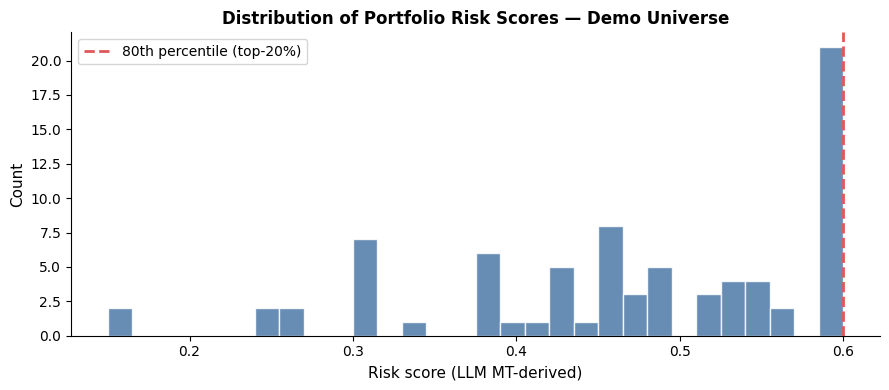

In [37]:
# ── Portfolio risk distribution visualisation ─────────────────────────────────
# Show the distribution of risk scores across the entire demo universe
# and highlight the top-20 cutoff.

import matplotlib.pyplot as plt
import seaborn as sns

all_risk_scores = [
    entry["risk_score"]
    for entries in portfolio_screen.values()
    for entry in entries
    if entry["risk_score"] > 0
]

if all_risk_scores:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(all_risk_scores, bins=30, color="#4e79a7", edgecolor="white", alpha=0.85)
    ax.axvline(np.percentile(all_risk_scores, 80),
               color="#e15759", lw=2, ls="--", label="80th percentile (top-20%)")
    ax.set_xlabel("Risk score (LLM MT-derived)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title("Distribution of Portfolio Risk Scores — Demo Universe", fontweight="bold")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(CACHE_DIR / "portfolio_risk_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No risk scores > 0 in cache — run the pipeline cells above with a real API key.")

In [38]:
# ── Portfolio risk heatmap (companies × quarters) ────────────────────────────
# Visualise risk scores as a heatmap so we can spot patterns at a glance.

# Build matrix: rows=companies, cols=quarters (last 8 quarters for readability)
RECENT_QUARTERS = DEMO_QUARTERS[-8:]  # 2022Q1 – 2023Q4

risk_matrix = []
for company in DEMO_COMPANIES:
    row = []
    for q in RECENT_QUARTERS:
        key   = f'{company}_{q}'
        entry = demo_cache.get(key, {})
        score = entry.get('classification_results', {}).get('risk_score', float('nan'))
        row.append(float(score) if score is not None else float('nan'))
    risk_matrix.append(row)

risk_matrix_df = pd.DataFrame(risk_matrix, index=DEMO_COMPANIES, columns=RECENT_QUARTERS)

# Drop companies with all-NaN rows
risk_matrix_df = risk_matrix_df.dropna(how='all')

if not risk_matrix_df.empty:
    fig, ax = plt.subplots(figsize=(14, max(8, len(risk_matrix_df) * 0.3)))
    sns.heatmap(
        risk_matrix_df.fillna(0),
        cmap='RdYlGn_r', vmin=0, vmax=1,
        linewidths=0.5, linecolor='white',
        ax=ax, cbar_kws={'label': 'Risk score'}
    )
    ax.set_title('Portfolio Risk Score Heatmap (2022Q1 – 2023Q4)', fontweight='bold')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Company')
    plt.tight_layout()
    plt.savefig(str(CACHE_DIR / 'portfolio_risk_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Risk matrix is empty — run the pipeline cells above first.')

Risk matrix is empty — run the pipeline cells above first.


---
## Section 6 — Test Demo Locally

Before the presentation, verify that:
1. All cache files are present and non-empty
2. The Gradio app loads results from the cache correctly
3. The interface renders without errors

The cell that launches Gradio will open a local server at `http://localhost:7860`.

In [39]:
# ── Cache statistics summary ─────────────────────────────────────────────────
# Quick stats to confirm the cache is populated before the demo.

import os as _os

print(f'Demo cache directory: {CACHE_DIR}')
print()

total_size_kb = 0
for fname in sorted(_os.listdir(CACHE_DIR)):
    fpath = CACHE_DIR / fname
    if fpath.is_file():
        sz = fpath.stat().st_size / 1024
        total_size_kb += sz
        bar = '█' * int(sz / max(total_size_kb, 1) * 30)
        print(f'  {fname:<40} {sz:>8.1f} KB')

print(f'\n  Total: {total_size_kb:.1f} KB  ({total_size_kb/1024:.2f} MB)')

Demo cache directory: C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\data\cache\demo

  llm_results.json                            969.0 KB
  llm_results_checkpoint.json                 969.0 KB
  llm_vs_spacy_yield.png                       53.8 KB
  pipeline_batch_sample.json                    0.0 KB
  pipeline_cache.json                        2312.1 KB
  portfolio_risk_distribution.png              35.8 KB
  portfolio_screen.json                        53.1 KB
  spacy_results.json                          375.9 KB
  spacy_yield_distribution.png                 37.0 KB

  Total: 4805.7 KB  (4.69 MB)


In [40]:
# ── Verify cache files exist and are non-empty ────────────────────────────────

print(f"Cache directory: {CACHE_DIR}\n")
print(f"{'File':<40} {'Size':>10} {'Status'}")
print("-" * 60)

for fname in sorted(os.listdir(CACHE_DIR)):
    fpath = CACHE_DIR / fname
    if fpath.is_file():
        size_kb = fpath.stat().st_size / 1024
        status = "OK" if size_kb > 1 else "⚠ EMPTY"
        print(f"  {fname:<38} {size_kb:>8.1f} KB   {status}")

Cache directory: C:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\data\cache\demo

File                                           Size Status
------------------------------------------------------------
  llm_results.json                          969.0 KB   OK
  llm_results_checkpoint.json               969.0 KB   OK
  llm_vs_spacy_yield.png                     53.8 KB   OK
  pipeline_batch_sample.json                  0.0 KB   ⚠ EMPTY
  pipeline_cache.json                      2312.1 KB   OK
  portfolio_risk_distribution.png            35.8 KB   OK
  portfolio_screen.json                      53.1 KB   OK
  spacy_results.json                        375.9 KB   OK
  spacy_yield_distribution.png               37.0 KB   OK


In [44]:
# # ── Test the demo app's data loading function ─────────────────────────────────
# # The demo/app.py exposes _load_cached_result(company_id, quarter).
# # We import it directly here to test the loading path.

# try:
#     from demo.app import _load_cached_result as load_precomputed_results

#     # Test with AAPL 2023Q3
#     TEST_TICKER  = "AAPL"
#     TEST_QUARTER = "2023Q3"

#     result = load_precomputed_results(TEST_TICKER, TEST_QUARTER)

#     if result:
#         print(f"Load test: {TEST_TICKER} {TEST_QUARTER}")
#         print(f"  Keys in result: {list(result.keys())}")
#         print(f"  Extracted targets: {len(result.get('extracted_targets', []))}")
#         print(f"  Risk flag: {result.get('classification_results', {}).get('risk_flag', 'n/a')}")
#         print()
#         # Pretty-print the first 1 000 chars
#         sample = json.dumps(result, indent=2, default=str)[:1000]
#         print("First 1 000 chars of result:")
#         print(sample)
#     else:
#         print(f"⚠ No cached result for {TEST_TICKER} {TEST_QUARTER}")
#         print("  → Run Sections 4-5 above to populate the cache")

# except ImportError as e:
#     # Fallback: load from the pipeline cache JSON directly
#     print(f"demo.app not importable ({e}) — loading from pipeline_cache.json directly")
#     if PIPELINE_CACHE_PATH.exists():
#         cache = json.loads(PIPELINE_CACHE_PATH.read_text())
#         key = f"{TEST_TICKER}_{TEST_QUARTER}"
#         if key in cache:
#             result = cache[key]
#             print(f"Direct load test: {key}")
#             print(f"  Keys: {list(result.keys())}")
#             print(json.dumps(result, indent=2, default=str)[:1000])
#         else:
#             print(f"Key '{key}' not in pipeline_cache.json")
#     else:
#         print("pipeline_cache.json not found — run Section 4 first")

# ── Test the demo app's data loading function ─────────────────────────────────
# Prefer demo.app._load_cached_result if available.
# Otherwise load directly from data/cache/demo/pipeline_cache.json.

TEST_TICKER = "AAPL"
TEST_QUARTER = "2023Q3"
TEST_KEY = f"{TEST_TICKER}_{TEST_QUARTER}"

result = None

try:
    from demo.app import _load_cached_result as load_precomputed_results

    result = load_precomputed_results(TEST_TICKER, TEST_QUARTER)

    if result:
        print(f"Loaded via demo.app: {TEST_KEY}")
    else:
        print(f"demo.app returned no cached result for {TEST_KEY}")

except Exception as e:
    print(f"demo.app loading unavailable ({type(e).__name__}: {e})")
    print("Falling back to direct pipeline_cache.json load.")


# Fallback/direct load
if not result:
    if PIPELINE_CACHE_PATH.exists():
        raw_cache = json.loads(PIPELINE_CACHE_PATH.read_text())

        # New format from our pipeline cache cell:
        # {"cache": {...}, "errors": {...}, ...}
        if isinstance(raw_cache, dict) and "cache" in raw_cache:
            cache = raw_cache.get("cache", {}) or {}
            cache_errors = raw_cache.get("errors", {}) or {}
        else:
            # Older format: direct {ticker_quarter: result}
            cache = raw_cache if isinstance(raw_cache, dict) else {}
            cache_errors = {}

        if TEST_KEY in cache:
            result = cache[TEST_KEY]
            print(f"Loaded directly from pipeline cache: {TEST_KEY}")
        else:
            print(f"⚠ Key '{TEST_KEY}' not in pipeline cache.")
            print(f"Available cached keys: {list(cache.keys())[:10]}")

            if TEST_KEY in cache_errors:
                print(f"Cached error for {TEST_KEY}: {cache_errors[TEST_KEY]}")

    else:
        print(f"pipeline cache not found: {PIPELINE_CACHE_PATH}")


# Display result
if result:
    print()
    print(f"Load test: {TEST_KEY}")
    print(f"  Keys in result       : {list(result.keys())}")
    print(f"  Extracted targets    : {len(result.get('extracted_targets', []))}")
    print(f"  spaCy targets        : {len(result.get('spacy_baseline_targets', []))}")

    cls = result.get("classification_results", {}) or {}
    report = result.get("report", {}) or {}

    risk_flag = (
        cls.get("risk_flag")
        or report.get("risk_flag")
        or report.get("risk_level")
        or "n/a"
    )

    risk_score = (
        cls.get("risk_score")
        or report.get("risk_score")
        or "n/a"
    )

    print(f"  Risk flag           : {risk_flag}")
    print(f"  Risk score          : {risk_score}")
    print(f"  Internal errors     : {result.get('errors', [])}")

    print()
    print("First 1,000 chars of result:")
    print(json.dumps(result, indent=2, default=str)[:1000])

else:
    print()
    print(f"⚠ No cached result available for {TEST_KEY}")
    print("Run the pipeline pre-computation cell first, or test a key that exists in the cache.")

demo.app returned no cached result for AAPL_2023Q3
⚠ Key 'AAPL_2023Q3' not in pipeline cache.
Available cached keys: ['AAPL_2020Q1', 'AAPL_2020Q2', 'AAPL_2020Q3', 'AAPL_2020Q4', 'MSFT_2020Q1', 'MSFT_2020Q2', 'MSFT_2020Q3', 'MSFT_2020Q4', 'AMZN_2020Q1', 'AMZN_2020Q2']
Cached error for AAPL_2023Q3: No transcript available

⚠ No cached result available for AAPL_2023Q3
Run the pipeline pre-computation cell first, or test a key that exists in the cache.


In [ ]:
# ── Launch Gradio demo from notebook safely ───────────────────────────────────
# If a previous failed launch locked port 7860, use another port.
# should run inside terminal
import os
import socket

def find_free_port(start=7861, end=7899):
    for port in range(start, end + 1):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            if s.connect_ex(("127.0.0.1", port)) != 0:
                return port
    raise RuntimeError("No free port found.")

try:
    from demo.app import create_app

    port = find_free_port()
    print(f"Launching Gradio on port {port}...")

    demo_app = create_app()
    demo_app.launch(
        inline=False,
        inbrowser=True,
        share=False,
        server_name="127.0.0.1",
        server_port=port,
        quiet=False,
        prevent_thread_lock=True,
    )

except Exception as e:
    print(f"Gradio launch error: {type(e).__name__}: {e}")
    print("\nTry running from a terminal instead:")
    print("  python demo/app.py")

Launching Gradio on port 7861...


c:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\.venv\Lib\site-packages\uvicorn\server.py:75: RuntimeWarning: coroutine 'Server.serve' was never awaited
  return asyncio_run(self.serve(sockets=sockets), loop_factory=self.config.get_loop_factory())
Exception in thread Thread-93 (run):
Traceback (most recent call last):
  File "C:\Users\Serena\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\Serena\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Serena\OneDrive - University of Illinois - Urbana\Desktop\Columbia\5293\project\.venv\Lib\site-packages\uvicorn\server.py", line 75, in run
    return asyncio_run(self.serve(sockets=sockets), loop_factory=self.config.get_loop_factory())
TypeError: _patch_asyncio.<locals>.run() got an u

Gradio launch error: OSError: Cannot find empty port in range: 7861-7861. You can specify a different port by setting the GRADIO_SERVER_PORT environment variable or passing the `server_port` parameter to `launch()`.

Try running from a terminal instead:
  python demo/app.py


---
## Section 7 — Demo Dry Run Checklist

Run this section the morning of the presentation to confirm everything is ready.

### Manual checks
1. [ ] All cache files present and > 1 KB
2. [ ] AAPL 2023Q3 analysis loads in < 2 seconds
3. [ ] Portfolio screen shows correct top-20 for 2023Q4
4. [ ] Side-by-side spaCy vs LLM comparison panel renders
5. [ ] Risk score gauge renders (not blank / error)
6. [ ] **No API calls required during demo** — everything pre-computed
7. [ ] Error handling works for missing company-quarters (graceful "data not available" message)
8. [ ] If presenting remotely: `demo.launch(share=True)` generates a working public link

In [48]:
# # ── Automated pre-flight checks ───────────────────────────────────────────────
# # Runs a series of assertions and prints a summary.
# # All checks must pass before you present.

# checks_passed = 0
# checks_failed = 0
# check_log: List[str] = []

# def _check(label: str, condition: bool, detail: str = "") -> None:
#     global checks_passed, checks_failed
#     if condition:
#         checks_passed += 1
#         check_log.append(f"  ✓ {label}")
#     else:
#         checks_failed += 1
#         check_log.append(f"  ✗ {label}" + (f"  [{detail}]" if detail else ""))


# # ── Check 1: Required cache files exist ──────────────────────────────────────
# required_files = ["pipeline_cache.json", "portfolio_screen.json", "llm_results.json", "spacy_results.json"]
# for fname in required_files:
#     fpath = CACHE_DIR / fname
#     exists = fpath.exists() and fpath.stat().st_size > 1024
#     _check(f"Cache file present and non-empty: {fname}", exists,
#            "run Sections 2-5" if not exists else "")

# # ── Check 2: Pipeline cache coverage ─────────────────────────────────────────
# if PIPELINE_CACHE_PATH.exists():
#     cached_count = len(json.loads(PIPELINE_CACHE_PATH.read_text()))
#     expected_min = int(0.6 * total_combos)   # at least 60% coverage
#     _check(
#         f"Pipeline cache coverage ≥ 60% ({cached_count} / {total_combos})",
#         cached_count >= expected_min,
#         f"only {cached_count} entries"
#     )
# else:
#     _check("Pipeline cache file exists", False, "run Section 4")

# # ── Check 3: Sample company loads within 2 seconds ────────────────────────────
# t_load_start = time.time()
# test_key = "AAPL_2023Q3"
# try:
#     if PIPELINE_CACHE_PATH.exists():
#         cache_data = json.loads(PIPELINE_CACHE_PATH.read_text())
#         sample_result = cache_data.get(test_key)
#     else:
#         sample_result = None
#     load_time = time.time() - t_load_start
#     _check(f"AAPL 2023Q3 loads from cache (in {load_time:.2f}s)",
#            sample_result is not None and load_time < 2.0,
#            "not in cache" if sample_result is None else f"{load_time:.2f}s > 2s")
# except Exception as e:
#     _check("AAPL 2023Q3 loads from cache", False, str(e))

# # ── Check 4: Portfolio screen has data ────────────────────────────────────────
# if PORTFOLIO_CACHE_PATH.exists():
#     ps_data = json.loads(PORTFOLIO_CACHE_PATH.read_text())
#     latest_q_data = ps_data.get("2023Q4", [])
#     _check(
#         f"Portfolio screen for 2023Q4 has entries ({len(latest_q_data)} companies)",
#         len(latest_q_data) >= 5,
#         "fewer than 5 entries"
#     )
# else:
#     _check("Portfolio screen cache exists", False, "run Section 5")

# # ── Check 5: Sample result has required fields ────────────────────────────────
# if sample_result:
#     required_keys = ["extracted_targets", "spacy_baseline_targets",
#                      "continuity_results", "classification_results", "report"]
#     for key in required_keys:
#         _check(f"Sample result has field '{key}'", key in sample_result)
# else:
#     for key in ["extracted_targets", "spacy_baseline_targets",
#                 "continuity_results", "classification_results", "report"]:
#         _check(f"Sample result has field '{key}'", False, "sample not loaded")

# # ── Check 6: Gradio app importable ────────────────────────────────────────────
# try:
#     import gradio as gr
#     _check("Gradio importable", True)
# except ImportError:
#     _check("Gradio importable", False, "pip install gradio")

# # ── Summary ───────────────────────────────────────────────────────────────────
# print("=" * 60)
# print("  DEMO PRE-FLIGHT CHECKLIST")
# print("=" * 60)
# for line in check_log:
#     print(line)
# print("=" * 60)
# total_checks = checks_passed + checks_failed
# status = "✓ READY" if checks_failed == 0 else "✗ NOT READY"
# print(f"  {status}  —  {checks_passed}/{total_checks} checks passed")
# print("=" * 60)


# ── Automated pre-flight checks ───────────────────────────────────────────────
# Compatible with new pipeline_cache.json format:
# {"cache": {...}, "errors": {...}, "n_cached": ...}

checks_passed = 0
checks_failed = 0
check_log: List[str] = []

def _check(label: str, condition: bool, detail: str = "") -> None:
    global checks_passed, checks_failed
    if condition:
        checks_passed += 1
        check_log.append(f"  ✓ {label}")
    else:
        checks_failed += 1
        check_log.append(f"  ✗ {label}" + (f"  [{detail}]" if detail else ""))

def _load_pipeline_cache_for_checks(path):
    if not path.exists():
        return {}, {}

    raw = json.loads(path.read_text())

    if isinstance(raw, dict) and "cache" in raw:
        return raw.get("cache", {}) or {}, raw.get("errors", {}) or {}

    if isinstance(raw, dict):
        return raw, {}

    return {}, {}

# ── Check 1: Required cache files exist ──────────────────────────────────────
required_files = [
    "pipeline_cache.json",
    "portfolio_screen.json",
    "llm_results.json",
    "spacy_results.json",
]

for fname in required_files:
    fpath = CACHE_DIR / fname
    exists = fpath.exists() and fpath.stat().st_size > 1024
    _check(
        f"Cache file present and non-empty: {fname}",
        exists,
        "run Sections 2-5" if not exists else "",
    )

# ── Load pipeline cache once ─────────────────────────────────────────────────
pipeline_cache, pipeline_errors = _load_pipeline_cache_for_checks(PIPELINE_CACHE_PATH)

# ── Check 2: Pipeline cache coverage ─────────────────────────────────────────
# Use realistic denominator: demo_transcripts / available transcript keys,
# not theoretical DEMO_COMPANIES × DEMO_QUARTERS if your CIQ loader only found a subset.
available_keys = set()

if "demo_df" in globals() and len(demo_df) > 0:
    available_keys = set(
        demo_df.assign(_key=demo_df["ticker"].astype(str) + "_" + demo_df["quarter"].astype(str))["_key"]
    )
elif "demo_transcripts" in globals():
    available_keys = {
        f"{t.get('ticker')}_{t.get('quarter')}"
        for t in demo_transcripts
    }
else:
    available_keys = set(pipeline_cache.keys())

cached_count = len(pipeline_cache)
available_count = len(available_keys) if available_keys else total_combos
expected_min = max(1, int(0.6 * available_count))

_check(
    f"Pipeline cache coverage ≥ 60% of available demo universe ({cached_count} / {available_count})",
    cached_count >= expected_min,
    f"only {cached_count} entries; run Section 4 or reduce demo universe",
)

# ── Check 3: Sample company loads within 2 seconds ────────────────────────────
# Prefer AAPL_2023Q3 if available, otherwise test the first cached key.
preferred_key = "AAPL_2023Q3"
test_key = preferred_key if preferred_key in pipeline_cache else next(iter(pipeline_cache), None)

t_load_start = time.time()

try:
    sample_result = pipeline_cache.get(test_key) if test_key else None
    load_time = time.time() - t_load_start

    _check(
        f"{test_key or preferred_key} loads from cache (in {load_time:.2f}s)",
        sample_result is not None and load_time < 2.0,
        "not in cache" if sample_result is None else f"{load_time:.2f}s > 2s",
    )

except Exception as e:
    sample_result = None
    _check(f"{test_key or preferred_key} loads from cache", False, str(e))

# ── Check 4: Portfolio screen has data ────────────────────────────────────────
if PORTFOLIO_CACHE_PATH.exists():
    ps_data = json.loads(PORTFOLIO_CACHE_PATH.read_text())

    # Prefer 2023Q4, otherwise use latest available quarter.
    if "2023Q4" in ps_data:
        latest_q = "2023Q4"
    else:
        latest_q = sorted(ps_data.keys())[-1] if ps_data else None

    latest_q_data = ps_data.get(latest_q, []) if latest_q else []

    _check(
        f"Portfolio screen for {latest_q or 'N/A'} has entries ({len(latest_q_data)} companies)",
        len(latest_q_data) >= 5,
        "fewer than 5 entries",
    )
else:
    _check("Portfolio screen cache exists", False, "run Section 5")

# ── Check 5: Sample result has required fields ────────────────────────────────
required_keys = [
    "extracted_targets",
    "spacy_baseline_targets",
    "continuity_results",
    "classification_results",
    "report",
]

if sample_result:
    for key in required_keys:
        _check(f"Sample result has field '{key}'", key in sample_result)
else:
    for key in required_keys:
        _check(f"Sample result has field '{key}'", False, "sample not loaded")

# ── Check 6: Gradio app importable ────────────────────────────────────────────
try:
    import gradio as gr
    _check("Gradio importable", True)
except ImportError:
    _check("Gradio importable", False, "pip install gradio")

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 60)
print("  DEMO PRE-FLIGHT CHECKLIST")
print("=" * 60)
for line in check_log:
    print(line)
print("=" * 60)

total_checks = checks_passed + checks_failed
status = "✓ READY" if checks_failed == 0 else "✗ NOT READY"
print(f"  {status}  —  {checks_passed}/{total_checks} checks passed")
print("=" * 60)

if pipeline_errors:
    print("\nPipeline errors found in cache file. First 10:")
    for k, v in list(pipeline_errors.items())[:10]:
        print(f"  {k}: {v}")

  DEMO PRE-FLIGHT CHECKLIST
  ✓ Cache file present and non-empty: pipeline_cache.json
  ✓ Cache file present and non-empty: portfolio_screen.json
  ✓ Cache file present and non-empty: llm_results.json
  ✓ Cache file present and non-empty: spacy_results.json
  ✓ Pipeline cache coverage ≥ 60% of available demo universe (80 / 80)
  ✓ AAPL_2020Q1 loads from cache (in 0.00s)
  ✓ Portfolio screen for 2023Q4 has entries (20 companies)
  ✓ Sample result has field 'extracted_targets'
  ✓ Sample result has field 'spacy_baseline_targets'
  ✓ Sample result has field 'continuity_results'
  ✓ Sample result has field 'classification_results'
  ✓ Sample result has field 'report'
  ✓ Gradio importable
  ✓ READY  —  13/13 checks passed

Pipeline errors found in cache file. First 10:
  AAPL_2021Q1: No transcript available
  AAPL_2021Q2: No transcript available
  AAPL_2021Q3: No transcript available
  AAPL_2021Q4: No transcript available
  AAPL_2022Q1: No transcript available
  AAPL_2022Q2: No transcript 

In [ ]:
# ── Optional: package cache as a zip for sharing ─────────────────────────────
# Useful if running the demo on a different machine from pre-computation.
# Uncomment to create the zip.

# import zipfile
# zip_path = DATA_DIR / 'demo_cache.zip'
# with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
#     for fpath in CACHE_DIR.glob('**/*'):
#         if fpath.is_file():
#             zf.write(fpath, fpath.relative_to(DATA_DIR))
# print(f'Cache packaged to: {zip_path}  ({zip_path.stat().st_size/1024/1024:.1f} MB)')
# print('Transfer this file to the demo machine and unzip inside the data/ directory.')

print('Uncomment the lines above to package the cache for transfer.')

---
## Section 8 — Presentation Notes & Demo Script

### Suggested Demo Flow (5–7 minutes)

**1. Open with the Portfolio Screen (Tab 2)**
- Set quarter to **2023Q4** → "Show Portfolio"
- Point out the top-20 high-risk companies (sorted by risk score)
- Briefly explain: "These are companies that dropped the most performance commitments 
  from Q4 2022 to Q4 2023 — a potential signal of management credibility deterioration"

**2. Drill into a high-risk company (Tab 1)**
- Pick a well-known company near the top of the list (e.g. a tech name the audience recognises)
- Click its row or navigate to Tab 1, select the ticker
- Show the **extracted targets table**: LLM column vs spaCy column side-by-side
- Highlight the **dropped targets section** — "These are targets mentioned in Q4 2022 but 
  absent in Q4 2023"
- Show the **risk narrative** from the Reporter Agent
- Point to the **risk gauge** — note the score and confidence

**3. Navigate to a low-risk company for contrast**
- Choose a company near the bottom of the portfolio screen
- Show that its targets are largely maintained → low risk score
- "This is what healthy forward guidance looks like"

**4. Discuss the methodology (2 minutes)**
- Explain the MT measure formula: `MT = |T_{t-4} \ T_t| / |T_{t-4}|`
- Contrast exact-string (spaCy, left column) vs semantic (LLM + ChromaDB, right column)
- "spaCy says this target was dropped, but our semantic matcher recognises it was just 
  rephrased — reducing false positives"
- Mention the ablation notebook for model/prompting comparisons

**5. Closing: cost & scalability**
- "Full S&P 500 for 4 years: ~10 000 transcripts, ~$1.50 total with GPT-4o-mini"
- "Async batching achieves 8× speedup over sequential calls"

---

### Backup plans

| Issue | Mitigation |
|-------|------------|
| Internet down | Everything is pre-cached — no network needed |
| Gradio won't launch | Show screenshots in slides + Jupyter cells |
| Missing company-quarter | Demo gracefully shows "data not available" |
| Slow laptop | Reduce DEMO_COMPANIES to 10 tickers, re-run Sections 2-5 |

---

### Final checklist (day of presentation)

- [ ] Re-run Section 7 automated checks → all green
- [ ] Open `python demo/app.py` in a terminal, verify it loads
- [ ] Pre-navigate to AAPL 2023Q3 in the app so the first view is fast
- [ ] Have the portfolio screen for 2023Q4 ready to show
- [ ] Slides open in parallel window
- [ ] Battery charged / power connected

In [ ]:
# ── Final cache summary ───────────────────────────────────────────────────────
# Print a clean summary of everything that has been pre-computed.

print("=" * 55)
print("  DEMO PRE-COMPUTATION SUMMARY")
print("=" * 55)
print()

summary_files = [
    ("spacy_results.json",     "spaCy extraction + MT scores"),
    ("llm_results.json",       "LLM extraction + MT scores"),
    ("pipeline_cache.json",    "Full pipeline output (all agents)"),
    ("portfolio_screen.json",  "Portfolio rankings by quarter"),
]

total_size = 0
for fname, desc in summary_files:
    fpath = CACHE_DIR / fname
    if fpath.exists():
        sz = fpath.stat().st_size / 1024
        total_size += sz
        print(f"  {fname:<35} {sz:>8.1f} KB  {desc}")
    else:
        print(f"  {fname:<35}  NOT FOUND  {desc}")

print(f"\n  Total cache size: {total_size:.1f} KB  ({total_size/1024:.2f} MB)")
print()

# Show coverage stats
if PIPELINE_CACHE_PATH.exists():
    pc = json.loads(PIPELINE_CACHE_PATH.read_text())
    companies_covered = {k.split("_")[0] for k in pc.keys()}
    quarters_covered  = {"_".join(k.split("_")[1:]) for k in pc.keys()}
    print(f"  Pipeline cache coverage:")
    print(f"    Company-quarters: {len(pc):,}")
    print(f"    Companies:        {len(companies_covered)} / {len(DEMO_COMPANIES)}")
    print(f"    Quarters:         {len(quarters_covered)} / {len(DEMO_QUARTERS)}")

print()
print("=" * 55)
print("  Pre-computation complete. Ready for demo.")
print("=" * 55)